# Melodies of Migration: How Conflict Shapes Music Culture
## Explainer Notebook

**Authors:** Beatricia Nagit (s253869), ... 

**Website:** [View the full interactive analysis](https://beatricia.github.io/CSS-Project-A/)

---

# 1. Motivation

## 1.1 What is your dataset?

**TODO:**
- [ ] Describe the three main datasets (Artist Database, Pageview Records, Lyrics & Sentiment)
- [ ] Add table with dataset sources, record counts, and descriptions
- [ ] Add Gabriel's dataset information
- [ ] Explain the geographic scope (5 conflict regions)
- [ ] Include conflict start dates table

## 1.2 Why did we choose this dataset?

**TODO:**
- [ ] Explain the research motivation (conflict's impact on music culture)
- [ ] Why music artists as a lens for studying conflict?
- [ ] What makes this dataset unique?

## 1.3 What was our goal for the end user's experience?

**TODO:**
- [ ] Describe target audiences (researchers, journalists, music fans, students)
- [ ] What insights should users take away?
- [ ] How does the website facilitate exploration?

In [1]:
# Setup and imports
import pandas as pd
import matplotlib.pyplot as plt
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
artists_df = pd.read_csv("../data/artists_data.csv")
pageviews_df = pd.read_csv("../data/monthly_pageviews.csv")

with open("../data/lyrics_data/raw_lyrics.json", "r", encoding="utf-8") as f:
    lyrics_data = json.load(f)
lyrics_df = pd.DataFrame(lyrics_data)

print("Datasets loaded successfully!")
print(f"  Artists: {len(artists_df):,}")
print(f"  Pageview records: {len(pageviews_df):,}")
print(f"  Songs with lyrics: {len(lyrics_df):,}")

Datasets loaded successfully!
  Artists: 1,637
  Pageview records: 10,350
  Songs with lyrics: 739


---

# 2. Basic Stats: Understanding the Dataset

## 2.1 Data Cleaning and Preprocessing

**TODO:**
- [ ] Describe artist data cleaning steps (deduplication, enrichment)
- [ ] Explain residence enrichment hierarchy
- [ ] Document geocoding approach (Nominatim, caching)
- [ ] Quality filtering criteria (English Wikipedia requirement)

ARTIST DISTRIBUTION BY COUNTRY
origin_country
Ukraine      495
Russia       491
Israel       488
Syria        119
Palestine     44
Name: count, dtype: int64

Total: 1,637 artists


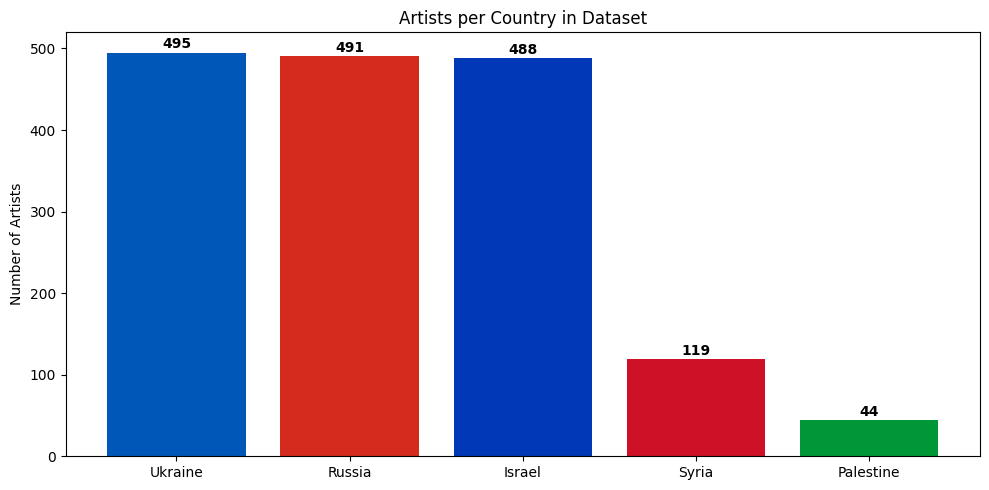

In [2]:
# Artist distribution by country
print("=" * 50)
print("ARTIST DISTRIBUTION BY COUNTRY")
print("=" * 50)

country_counts = artists_df['origin_country'].value_counts()
print(country_counts)
print(f"\nTotal: {len(artists_df):,} artists")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Ukraine': '#0057B7', 'Russia': '#D52B1E', 'Israel': '#0038B8', 
          'Palestine': '#009736', 'Syria': '#CE1126'}
bars = ax.bar(country_counts.index, country_counts.values, 
              color=[colors.get(c, 'gray') for c in country_counts.index])
ax.set_ylabel('Number of Artists')
ax.set_title('Artists per Country in Dataset')
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Why the Imbalance?

**TODO:**
- [ ] Explain dataset imbalance (Ukraine/Russia/Israel ~490 vs Palestine ~44)
- [ ] Discuss Wikidata data sparsity for conflict regions
- [ ] Note limitations of using Wikipedia as data source

In [ ]:
# Data completeness analysis
print("=" * 50)
print("DATA COMPLETENESS")
print("=" * 50)

completeness = {
    'Has birth_place': artists_df['birth_place'].notna().sum(),
    'Has current_residence': artists_df['current_residence'].notna().sum(),
    'Has wiki_url': artists_df['wiki_url'].notna().sum(),
}

for field, count in completeness.items():
    pct = count / len(artists_df) * 100
    print(f"{field}: {count:,} ({pct:.1f}%)")

In [ ]:
# Pageview data coverage
print("=" * 50)
print("PAGEVIEW DATA COVERAGE")
print("=" * 50)

pageview_coverage = pageviews_df.groupby('origin_country').agg({
    'wikidata_id': 'nunique',
    'views': ['sum', 'mean'],
    'month': ['min', 'max']
}).round(0)

pageview_coverage.columns = ['Unique Artists', 'Total Views', 'Avg Views/Record', 'First Month', 'Last Month']
print(pageview_coverage)

print(f"\nTotal pageview records: {len(pageviews_df):,}")
print(f"Total views tracked: {pageviews_df['views'].sum():,.0f}")

## 2.2 Lyrics Dataset Statistics

**TODO:**
- [ ] Summarize lyrics dataset (total songs, artists, countries)
- [ ] Discuss year range coverage
- [ ] Note any language considerations

In [ ]:
# Lyrics dataset overview
print("=" * 50)
print("LYRICS DATASET OVERVIEW")
print("=" * 50)

print(f"Total songs: {len(lyrics_df):,}")
print(f"Unique artists: {lyrics_df['artist'].nunique()}")
print(f"Countries represented: {lyrics_df['country'].nunique()}")

print("\nSongs per country:")
print(lyrics_df['country'].value_counts())

print("\nYear range:")
years = pd.to_numeric(lyrics_df['year'], errors='coerce').dropna()
print(f"  Earliest: {int(years.min())}")
print(f"  Latest: {int(years.max())}")

---

# 3. Tools, Theory and Analysis

## 3.1 Working with Text: Lyrics Processing

**TODO:**
- [ ] Describe text cleaning pipeline (remove markers, handle Unicode)
- [ ] Explain multi-script considerations (Cyrillic, Hebrew, Arabic)
- [ ] Document VADER sentiment analysis choice and methodology
- [ ] Explain compound score interpretation (-1 to +1)

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Example of VADER analysis
analyzer = SentimentIntensityAnalyzer()

examples = [
    "I love you with all my heart",
    "The war destroyed everything we had",
    "We will rise again, stronger than before",
    "Silence. Death. Nothing remains."
]

print("VADER Sentiment Examples:")
print("-" * 60)
for text in examples:
    scores = analyzer.polarity_scores(text)
    print(f"Text: \"{text}\"")
    print(f"  Compound: {scores['compound']:.3f} | Pos: {scores['pos']:.3f} | Neg: {scores['neg']:.3f}")
    print()

## 3.2 Geographic Analysis Strategy

**TODO:**
- [ ] Explain migration flow analysis (birth place → current residence)
- [ ] Document geocoding approach (Nominatim, rate limiting, caching)
- [ ] Justify Folium choice for visualization
- [ ] Describe map types (birth place, current residence, migration)

In [ ]:
# Migration pattern analysis
print("=" * 50)
print("MIGRATION PATTERN ANALYSIS")
print("=" * 50)

# Count artists who moved vs stayed
artists_with_both = artists_df.dropna(subset=['birth_place', 'current_residence'])
moved = artists_with_both[artists_with_both['birth_place'] != artists_with_both['current_residence']]
stayed = artists_with_both[artists_with_both['birth_place'] == artists_with_both['current_residence']]

print(f"Artists with both birth place and residence data: {len(artists_with_both)}")
print(f"  Relocated: {len(moved)} ({len(moved)/len(artists_with_both)*100:.1f}%)")
print(f"  Stayed: {len(stayed)} ({len(stayed)/len(artists_with_both)*100:.1f}%)")

print("\nRelocation rate by country:")
for country in artists_df['origin_country'].unique():
    country_artists = artists_with_both[artists_with_both['origin_country'] == country]
    if len(country_artists) > 0:
        country_moved = country_artists[country_artists['birth_place'] != country_artists['current_residence']]
        rate = len(country_moved) / len(country_artists) * 100
        print(f"  {country}: {rate:.1f}% relocated")

## 3.3 Pageview Analysis: Measuring Global Attention

**TODO:**
- [ ] Explain why Wikipedia pageviews measure global attention
- [ ] Document API methodology (article extraction, monthly aggregation)
- [ ] Describe pre/post conflict comparison approach

In [ ]:
# Pre vs Post conflict analysis
CONFLICT_DATES = {
    "Ukraine": "2022-02",
    "Russia": "2022-02",
    "Syria": "2011-03",
    "Israel": "2023-10",
    "Palestine": "2023-10"
}

print("=" * 50)
print("PAGEVIEW CHANGE ANALYSIS")
print("=" * 50)

for country, conflict_month in CONFLICT_DATES.items():
    country_data = pageviews_df[pageviews_df['origin_country'] == country]
    
    if len(country_data) == 0:
        print(f"\n{country}: No pageview data available")
        continue
    
    before = country_data[country_data['month'] < conflict_month]['views']
    after = country_data[country_data['month'] >= conflict_month]['views']
    
    if len(before) > 0 and len(after) > 0:
        avg_before = before.sum() / before.groupby(country_data[country_data['month'] < conflict_month]['month']).ngroups
        avg_after = after.sum() / after.groupby(country_data[country_data['month'] >= conflict_month]['month']).ngroups
        change = (avg_after - avg_before) / avg_before * 100 if avg_before > 0 else 0
        
        print(f"\n{country} (conflict: {conflict_month}):")
        print(f"  Avg monthly views before: {avg_before:,.0f}")
        print(f"  Avg monthly views after: {avg_after:,.0f}")
        print(f"  Change: {change:+.1f}%")

## 3.4 Sentiment Over Time

**TODO:**
- [ ] Explain pre vs post conflict song classification
- [ ] State hypothesis (conflict → more negative sentiment)
- [ ] Discuss expected patterns

In [ ]:
# Load sentiment data
sentiment_df = pd.read_csv("../data/lyrics_data/lyrics_with_sentiment.csv")

print("=" * 50)
print("SENTIMENT BY PERIOD")
print("=" * 50)

period_sentiment = sentiment_df.groupby(['country', 'period'])['compound'].agg(['mean', 'count'])
print(period_sentiment)

## 3.5 Network Analysis: Artist Collaborations

**TODO:**
- [ ] Explain why network analysis for music (collaborations, features)
- [ ] Define network structure (nodes = artists, edges = collaborations)
- [ ] List network metrics to use (degree, betweenness, clustering, communities)
- [ ] Describe data source for collaboration data

In [ ]:
# Network Analysis - Placeholder
# This section will be populated once collaboration data is collected

import networkx as nx

print("=" * 50)
print("NETWORK ANALYSIS (Coming Soon)")
print("=" * 50)

print("""
Planned network analysis:

1. Artist Collaboration Network
   - Nodes: Artists from our dataset
   - Edges: Collaborations (featured tracks, joint albums)
   
2. Key Metrics to Calculate:
   - Network size and density
   - Degree distribution
   - Top 10 most connected artists
   - Community detection (Louvain algorithm)
   - Cross-country collaboration patterns
   
3. Visualizations:
   - Interactive network graph (using pyvis or networkx)
   - Collaboration heatmap by country
   - Centrality rankings

Status: Awaiting collaboration data collection
""")

---

# 4. Discussion

## 4.1 What Went Well

**TODO:**
- [ ] List successful aspects (multi-source integration, visualizations, etc.)
- [ ] Summarize key findings for each country
- [ ] Highlight notable patterns discovered

## 4.2 What Could Be Improved

**TODO:**
- [ ] Document data limitations (Palestine sparsity, Syria temporal gap, etc.)
- [ ] List methodological improvements (additional languages, streaming data, etc.)
- [ ] Propose future work directions

In [ ]:
# Summary statistics for reference
print("=" * 60)
print("PROJECT SUMMARY STATISTICS")
print("=" * 60)

print(f"""
📊 DATASET OVERVIEW
   Total artists: {len(artists_df):,}
   Pageview records: {len(pageviews_df):,}
   Songs analyzed: {len(lyrics_df):,}
   Countries covered: 5 (Ukraine, Russia, Israel, Palestine, Syria)

📍 GEOGRAPHIC COVERAGE
   Unique birth places: {artists_df['birth_place'].nunique()}
   Unique current residences: {artists_df['current_residence'].nunique()}

📈 PAGEVIEW COVERAGE
   Total views tracked: {pageviews_df['views'].sum():,.0f}
   Date range: {pageviews_df['month'].min()} to {pageviews_df['month'].max()}

🎵 LYRICS ANALYSIS
   Artists with lyrics: {lyrics_df['artist'].nunique()}
   Average sentiment: {sentiment_df['compound'].mean():.3f}
""")

---

## References & Data Sources

**TODO:**
- [ ] List APIs used (Wikidata, Wikipedia Pageviews, Genius, Nominatim)
- [ ] List Python libraries (pandas, folium, matplotlib, vaderSentiment, etc.)
- [ ] Document conflict dates with sources